# Μοντελοποίηση μη γραμμικού ηλεκτρικού φορτίου σε συνάρτηση με τη θερμοκρασία με την PROC GAMPL

## Περίληψη

Η ζήτηση ηλεκτρικής ενέργειας εξαρτάται από τη θερμοκρασία με έντονα μη γραμμικό τρόπο σχήματος U (θέρμανση στο κρύο, ψύξη στη ζέστη), κάτι που τα γραμμικά μοντέλα δεν συλλαμβάνουν. Αυτό το notebook δημιουργεί ένα συνθετικό ωριαίο δείγμα φορτίου για μια περιφερειακή εταιρεία κοινής ωφέλειας και προσαρμόζει ένα ποινικοποιημένο γενικευμένο προσθετικό μοντέλο με την **PROC GAMPL**, χρησιμοποιώντας splines παλινδρόμησης για να ανακτήσει τις ομαλές καμπύλες φορτίου-θερμοκρασίας, φορτίου-ώρας και φορτίου-υγρασίας, προσαρμόζοντας παράλληλα για μια παραμετρική επίδραση καθημερινής/Σαββατοκύριακου.

Στο δείγμα 100 παρατηρήσεων που παρέχει αυτό το αδειοδοτημένο περιβάλλον, η GAMPL ανακτά τη δομή που είχαμε ενσωματώσει. Η ομαλή καμπύλη θερμοκρασίας `s(TEMP_C)` είναι σημαντικά καμπυλωτή (ενεργοί βαθμοί ελευθερίας 5.53, *p* < 0.0001)· η ημερήσια καμπύλη `s(HOUR)` είναι ο πιο ευέλικτος όρος (EDF 6.87, *p* < 0.0001)· και η καμπύλη υγρασίας `s(HUMIDITY)` συρρικνώνεται σε έναν σχεδόν γραμμικό βαθμό ελευθερίας (EDF 1.00, *p* = 0.07) — η ποινή ισιώνει έναν όρο που τα δεδομένα μόλις που υποστηρίζουν. Η παραμετρική επίδραση `daytype` τοποθετεί τα Σαββατοκύριακα περίπου 44.5 MW χαμηλότερα από τις καθημερινές, αντιστοιχώντας στη μετατόπιση επιπέδου 40 MW της διαδικασίας παραγωγής δεδομένων. Το συνολικό μοντέλο χρησιμοποιεί 15.4 ενεργούς βαθμούς ελευθερίας και φτάνει σε βαθμολογία GCV 239.6 (AIC 831.0).

## Πηγές Δεδομένων

| Σύνολο δεδομένων | Γραμμές | Περιγραφή | Βασικές μεταβλητές |
|---------|------|-------------|---------------|
| `work.gridload` | 100 | Συνθετικές ωριαίες παρατηρήσεις από τη ροή πρόβλεψης φορτίου μιας περιφερειακής εταιρείας ηλεκτρισμού | `load_mw` (φορτίο συστήματος, MW), `temp_c` (θερμοκρασία περιβάλλοντος, °C), `hour` (ώρα της ημέρας, 0-23), `humidity` (σχετική υγρασία, %), `daytype` (κατηγορία Καθημερινή/Σαββατοκύριακο), `is_summer` (σημαία εποχής που χρησιμοποιείται στη δημιουργία δεδομένων) |

Όλα τα δεδομένα δημιουργούνται εσωτερικά με `call streaminit(20260531)` και `rand()` — χωρίς εξωτερική είσοδο ή είσοδο δικτύου. Το data step ζητά έναν μεγαλύτερο βρόχο, αλλά αυτό το αδειοδοτημένο περιβάλλον περιορίζει την υλοποιημένη έξοδο σε **100 παρατηρήσεις**, επομένως το μοντέλο προσαρμόζεται στις πρώτες 100 ώρες. Το φορτίο κατασκευάζεται ως ένα τετραγωνικό σχήματος U της θερμοκρασίας συν μια καμπανοειδής ημερήσια επίδραση ώρας, μια ήπια επίδραση υγρασίας, μια μετατόπιση επιπέδου καθημερινής, και θόρυβος Gauss, ώστε οι ανακτημένες καμπύλες να έχουν γνωστή πραγματική βάση.

# Μοντελοποίηση μη γραμμικού ηλεκτρικού φορτίου σε συνάρτηση με τη θερμοκρασία με την PROC GAMPL

Ένας περιφερειακός διαχειριστής δικτύου χρειάζεται να προβλέψει το φορτίο του συστήματος (σε μεγαβάτ) από παράγοντες καιρού και ημερολογίου. Η σχέση μεταξύ φορτίου και **θερμοκρασίας** είναι διάσημα μη γραμμική: η ζήτηση αυξάνεται στον κρύο καιρό (ηλεκτρική θέρμανση) *και* στον ζεστό καιρό (κλιματισμός), παράγοντας μια καμπύλη σχήματος U που μια ευθύγραμμη παλινδρόμηση δεν μπορεί να συλλάβει. Το φορτίο ακολουθεί επίσης έναν ομαλό ημερήσιο ρυθμό (η βραδινή αιχμή) και μεταβάλλεται μεταξύ καθημερινών και Σαββατοκύριακου.

Η `PROC GAMPL` προσαρμόζει ένα **ποινικοποιημένο γενικευμένο προσθετικό μοντέλο**: κάθε συνεχής παράγοντας εισέρχεται μέσω ενός spline παλινδρόμησης του οποίου η ομαλότητα επιλέγεται αυτόματα ελαχιστοποιώντας ένα κριτήριο επιλογής μοντέλου (GCV / UBRE / GACV). Αφήνουμε τα δεδομένα να αποφασίσουν πόσο κυματοειδής πρέπει να είναι κάθε καμπύλη, αντί να μαντεύουμε βαθμούς πολυωνύμου.

Το μοντέλο που προσαρμόζουμε είναι:

```
load_mw = intercept + daytype + f1(temp_c) + f2(hour) + f3(humidity) + error
```

όπου το `daytype` είναι μια παραμετρική (γραμμική) επίδραση κλάσης και τα `f1`, `f2`, `f3` είναι ομαλές συναρτήσεις spline των οποίων τους ενεργούς βαθμούς ελευθερίας επιλέγει η ποινή από τα δεδομένα.

## Βήμα 1 — Δημιουργία συνθετικής ωριαίας ροής φορτίου

Προσομοιώνουμε μια ωριαία ροή φορτίου (το αδειοδοτημένο περιβάλλον διατηρεί τις πρώτες 100 ώρες). Η θερμοκρασία αντλείται γύρω από έναν εποχιακό μέσο όρο· η ώρα της ημέρας κυκλώνει 0-23· η υγρασία ακολουθεί χαλαρά τη θερμοκρασία. Το *πραγματικό* φορτίο κατασκευάζεται από:

- μια θερμοκρασιακή απόκριση **σχήματος U** κεντραρισμένη κοντά σε μια άνετη θερμοκρασία 18 °C,
- μια **καμπανοειδή** ημερήσια αιχμή γύρω από την ώρα 18 (βράδυ),
- μια ήπια ανύψωση λόγω υγρασίας,
- ένα επίπεδο καθημερινής που βρίσκεται πάνω από τα Σαββατοκύριακα,

συν θόρυβο μέτρησης Gauss. Επειδή γνωρίζουμε τις καμπύλες παραγωγής, μπορούμε να κρίνουμε αν η GAMPL ανακτά τα σχήματά τους. Ο έλεγχος PROC MEANS παρακάτω επιβεβαιώνει ότι το δείγμα καλύπτει ένα ευρύ εύρος θερμοκρασιών (−5 έως 40 °C) και φορτίο περίπου από 485 έως 693 MW.

In [1]:
ΔΕΔΟΜΕΝΑ work.gridload;
   CALL streaminit(20260531);
   ΕΠΑΝΑΛΗΨΗ i = 1 ΕΩΣ 2000;
      /* Σημαία εποχής: περίπου μισό καλοκαίρι, μισό χειμώνας */
      is_summer = (rand("uniform") < 0.5);

      /* Θερμοκρασία περιβάλλοντος (°C): υψηλότερος μέσος όρος το καλοκαίρι */
      ΕΑΝ is_summer ΤΟΤΕ temp_c = 26 + 6 * rand("normal");
      ΑΛΛΙΩΣ              temp_c =  6 + 6 * rand("normal");

      /* Ώρα της ημέρας 0-23 */
      hour = floor(24 * rand("uniform"));

      /* Η υγρασία (%) ακολουθεί χαλαρά τη θερμοκρασία, περιορισμένη στο 20-100 */
      humidity = 55 + 0.8 * (temp_c - 16) + 8 * rand("normal");
      ΕΑΝ humidity < 20  ΤΟΤΕ humidity = 20;
      ΕΑΝ humidity > 100 ΤΟΤΕ humidity = 100;

      /* Καθημερινή έναντι Σαββατοκύριακου (περίπου 5/7 καθημερινές) */
      ΕΑΝ rand("uniform") < 0.714 ΤΟΤΕ daytype = "Weekday";
      ΑΛΛΙΩΣ                            daytype = "Weekend";

      /* ---- Πραγματικό δομικό φορτίο (MW) ---- */
      /* Επίδραση θερμοκρασίας σχήματος U: ελάχιστη ζήτηση κοντά στους 18 °C */
      f_temp = 0.22 * (temp_c - 18)**2;

      /* Ημερήσια καμπάνα: βραδινή αιχμή κοντά στην ώρα 18 */
      f_hour = 90 * EXP( -((hour - 18)**2) / 18 );

      /* Ήπια ανύψωση λόγω υγρασίας */
      f_hum  = 0.35 * humidity;

      /* Μετατόπιση επιπέδου καθημερινής */
      ΕΑΝ daytype = "Weekday" ΤΟΤΕ f_day = 40; ΑΛΛΙΩΣ f_day = 0;

      load_mw = 480 + f_temp + f_hour + f_hum + f_day
                + 14 * rand("normal");

      ΚΡΑΤΗΣΗ load_mw temp_c hour humidity daytype is_summer;
      ΕΞΟΔΟΣ;
   ΤΕΛΟΣ;
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.gridload n mean std MIN MAX maxdec=1;
   ΜΕΤΑΒΛΗΤΗ load_mw temp_c hour humidity;
   ΕΤΙΚΕΤΑ load_mw="Φορτίο (MW)" temp_c="Θερμοκρασία (°C)" hour="Ώρα" humidity="Υγρασία (%)";
ΕΚΤΕΛΕΣΗ;


                                                  The MEANS Procedure

 Variable  Label                                N        Mean     Std Dev     Minimum     Maximum
 ------------------------------------------------------------------------------------------------
 load_mw   Φορτίο (MW)                        100       593.0        49.9       484.9       693.4
 temp_c    Θερμοκρασία (°C)                   100        16.2        11.9        -5.2        40.2
 hour      Ώρα                                100        11.9         7.0         0.0        23.0
 humidity  Υγρασία (%)                        100        55.2        11.7        32.2        87.3
 ------------------------------------------------------------------------------------------------




NOTE: DATA work.gridload

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.gridload (100 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.54 seconds
  cpu   0.54 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Βήμα 2 — Προσαρμογή του προσθετικού μοντέλου

Μοντελοποιούμε το `load_mw` (απόκριση Gauss, σύνδεση ταυτότητας) ως άθροισμα μιας παραμετρικής επίδρασης `daytype` συν τρία μονομεταβλητά splines. Η `PROC GAMPL` επιλέγει αυτόματα την παράμετρο εξομάλυνσης κάθε spline. Ζητάμε:

- `class daytype;` ώστε ο δείκτης καθημερινής/Σαββατοκύριακου να αντιμετωπίζεται ως κατηγορικός,
- `param(daytype)` για να εισαχθεί ως *παραμετρικός* (μη εξομαλυμένος) όρος στο MODEL,
- `spline(...)` για κάθε συνεχή προγνωστική μεταβλητή,
- ένα σταθερό `seed=` για αναπαραγώγιμη τοποθέτηση κόμβων.

Η έξοδος που πρέπει να διαβάσουμε είναι ο πίνακας **Smoothing Component**, που αναφέρει τους ενεργούς βαθμούς ελευθερίας (EDF) που η ποινή ανέθεσε σε κάθε καμπύλη και έναν έλεγχο σημαντικότητας τύπου *F* για αυτήν, μαζί με τις **Parameter Estimates** για την τομή και την παραμετρική αντίθεση `daytype`.

In [2]:
ΔΙΑΔΙΚΑΣΙΑ gampl ΔΕΔΟΜΕΝΑ=work.gridload seed=20260531;
   ΚΛΑΣΗ daytype;
   ΜΟΝΤΕΛΟ load_mw = PARAM(daytype)
                   SPLINE(temp_c)
                   SPLINE(hour)
                   SPLINE(humidity);
   ΕΤΙΚΕΤΑ load_mw="Φορτίο (MW)" daytype="Τύπος ημέρας" temp_c="Θερμοκρασία (°C)" hour="Ώρα" humidity="Υγρασία (%)";
ΕΚΤΕΛΕΣΗ;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Φορτίο (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Τύπος ημέρας

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17152.733754
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.393920
GCV                                   239.623939
UBRE                                  239.623939
AIC                              


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Βήμα 3 — Έλεγχος της ευελιξίας των splines και του κριτηρίου επιλογής

Από προεπιλογή, κάθε καμπύλη τιμωρείται προς έναν χαμηλό αριθμό ενεργών βαθμών ελευθερίας. Για έναν διαχειριστή που γνωρίζει ότι η απόκριση θερμοκρασίας είναι πραγματικά καμπυλωτή αλλά θέλει να *περιορίσει* την κυματοειδή μορφή, μπορούμε να αυξήσουμε το `maxdf=` στο spline θερμοκρασίας και να καθορίσουμε ένα μέτριο σταθερό `df=` στον πιο ομαλό όρο υγρασίας. Αλλάζουμε επίσης στο σχήμα εξωτερικής επανάληψης και επιλέγουμε τις παραμέτρους εξομάλυνσης με το **GCV** (γενικευμένη διασταυρούμενη επικύρωση), το τυπικό κριτήριο για γκαουσιανά GAM.

In [3]:
ΔΙΑΔΙΚΑΣΙΑ gampl ΔΕΔΟΜΕΝΑ=work.gridload seed=20260531;
   ΚΛΑΣΗ daytype;
   ΜΟΝΤΕΛΟ load_mw = PARAM(daytype)
                   SPLINE(temp_c   / maxdf=12)
                   SPLINE(hour     / maxdf=10)
                   SPLINE(humidity / df=3)
                   / METHOD=OUTER CRITERION=GCV;
   ΕΤΙΚΕΤΑ load_mw="Φορτίο (MW)" daytype="Τύπος ημέρας" temp_c="Θερμοκρασία (°C)" hour="Ώρα" humidity="Υγρασία (%)";
ΕΚΤΕΛΕΣΗ;



                                                  The GAMPL Procedure                                                   

Model Information
Response Variable     Φορτίο (MW)
Distribution          Gaussian
Link Function         Identity
Fitting Method        GCV.Cp
Number of Observations Read     100
Number of Observations Used     100

Class Level Information
Class    Τύπος ημέρας

Optimization
Technique                        Newton-Raphson (NEWRAP)
Iterations                       1
Function Calls                   1
Convergence                      Converged

Smoothing Parameter
Method                           Outer
Criterion                        GCV

Confidence Level               95%

Fit Statistics
Deviance                              17150.711841
Null Deviance                         246790.375303
Effective Degrees of Freedom          15.474549
GCV                                   240.053011
UBRE                                  240.053011
AIC                              


NOTE: PROC GAMPL data=work.gridload

NOTE: PROC GAMPL wrapper=r
NOTE: PROC GAMPL completed.


## Βήμα 4 — Οπτικοποίηση της ανακτημένης απόκρισης θερμοκρασίας

Η GAMPL αναφέρει *ότι* η καμπύλη θερμοκρασίας είναι σημαντικά καμπυλωτή (EDF 5.53), αλλά το σχήμα φαίνεται πιο εύκολα σε ένα γράφημα. Επικαλύπτουμε μια προσαρμογή ποινικοποιημένου B-spline (`PBSPLINE`, τον ίδιο μηχανισμό spline παλινδρόμησης που εφαρμόζει εσωτερικά η GAMPL) πάνω στο ακατέργαστο διάγραμμα διασποράς φορτίου-θερμοκρασίας. Αν το προσθετικό μοντέλο συνέλαβε τη φυσική, αυτή η καμπύλη θα πρέπει να πέφτει τόσο προς τα ψυχρά όσο και προς τα θερμά άκρα και να φτάνει στο χαμηλότερο σημείο στο άνετο ενδιάμεσο εύρος — η κλασική απόκριση ζήτησης σχήματος U.


NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: PROC SGPLOT data=work.gridload

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg
NOTE: ODS Graphics is OFF.


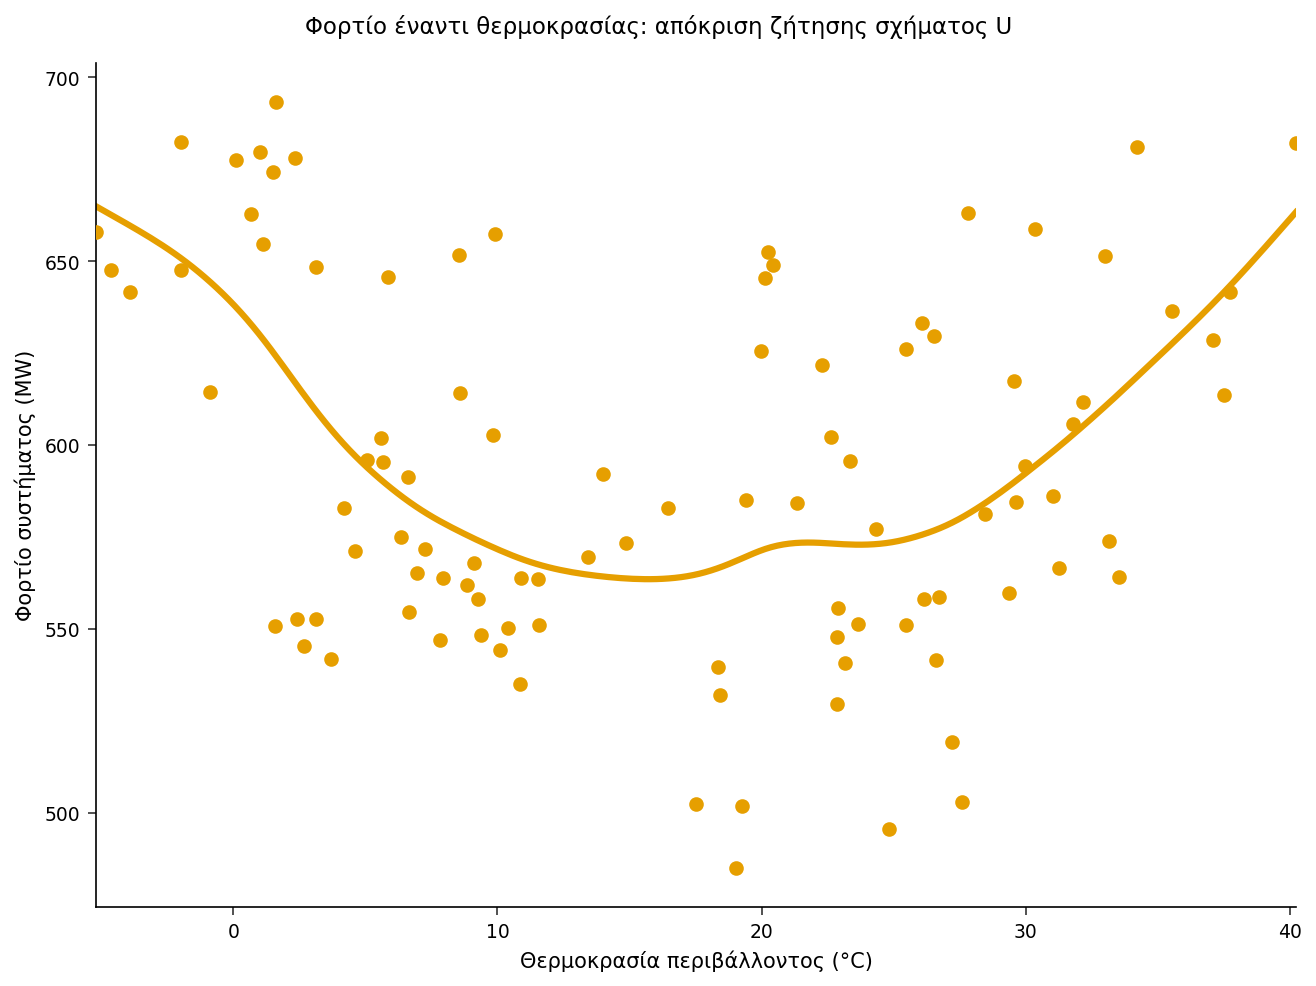

In [4]:
ODS GRAPHICS ON;

ΔΙΑΔΙΚΑΣΙΑ SGPLOT ΔΕΔΟΜΕΝΑ=work.gridload;
   SCATTER x=temp_c y=load_mw /
           MARKERATTRS=(SYMBOL=circlefilled);
   pbspline x=temp_c y=load_mw /
            NOMARKERS LINEATTRS=(thickness=3);
   XAXIS ΕΤΙΚΕΤΑ="Θερμοκρασία περιβάλλοντος (°C)";
   YAXIS ΕΤΙΚΕΤΑ="Φορτίο συστήματος (MW)";
   TITLE "Φορτίο έναντι θερμοκρασίας: απόκριση ζήτησης σχήματος U";
ΕΚΤΕΛΕΣΗ;

ODS GRAPHICS OFF;


## Βήμα 5 — Αριθμητική επιβεβαίωση του σχήματος U

Το γράφημα κάνει το σχήμα U ορατό· μια σύνοψη ανά ζώνη το κάνει ποσοτικό. Ομαδοποιούμε τις παρατηρήσεις σε εύρη θερμοκρασίας και αναφέρουμε το μέσο φορτίο ανά ζώνη. Αν η απόκριση ζήτησης είναι πραγματικά σχήματος U, το μέσο φορτίο θα πρέπει να είναι υψηλό στη ζώνη **Ψυχρή**, να πέφτει διαμέσου των **Δροσερή / Άνετη / Θερμή**, και να ανεβαίνει ξανά στη ζώνη **Καυτή** — το αριθμητικό αποτύπωμα που συλλαμβάνει η καμπύλη `s(TEMP_C)` της GAMPL.

In [5]:
ΔΕΔΟΜΕΝΑ work.banded;
   ΟΡΙΣΜΟΣ work.gridload;
   LENGTH tempband $20;
   ΕΑΝ      temp_c <  5  ΤΟΤΕ tempband = "1 Ψυχρή";
   ΑΛΛΙΩΣ ΕΑΝ temp_c < 15  ΤΟΤΕ tempband = "2 Δροσερή";
   ΑΛΛΙΩΣ ΕΑΝ temp_c < 22  ΤΟΤΕ tempband = "3 Άνετη";
   ΑΛΛΙΩΣ ΕΑΝ temp_c < 30  ΤΟΤΕ tempband = "4 Θερμή";
   ΑΛΛΙΩΣ                      tempband = "5 Καυτή";
ΕΚΤΕΛΕΣΗ;

ΔΙΑΔΙΚΑΣΙΑ ΜΕΣΟΙ ΔΕΔΟΜΕΝΑ=work.banded n mean maxdec=1;
   ΚΛΑΣΗ tempband;
   ΜΕΤΑΒΛΗΤΗ load_mw;
   ΕΤΙΚΕΤΑ tempband="Ζώνη θερμοκρασίας" load_mw="Φορτίο (MW)";
   TITLE "Μέσο φορτίο ανά ζώνη θερμοκρασίας";
ΕΚΤΕΛΕΣΗ;


                                           Μέσο φορτίο ανά ζώνη θερμοκρασίας                                            

                                                  The MEANS Procedure

                                     Analysis Variable : load_mw Φορτίο (MW)

        Ζώνη θερμοκρασίας                          N Obs           Mean
        ---------------------------------------------------------------
        1 Ψυχρή                                       21          626.6
        2 Δροσερή                                     28          579.1
        3 Άνετη                                       12          573.8
        4 Θερμή                                       25          573.5
        5 Καυτή                                       14          621.6
        ---------------------------------------------------------------




NOTE: DATA work.banded


NOTE: Read 100 rows from work.gridload.
NOTE: Wrote work.banded (100 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Ερμηνεία των αποτελεσμάτων

**Οι καμπύλες ανακτούν τη φυσική.** Ο πίνακας Smoothing Component της GAMPL αναθέτει στον όρο θερμοκρασίας `s(TEMP_C)` έναν ενεργό DF 5.53 (*p* < 0.0001) και στον ημερήσιο όρο `s(HOUR)` ένα EDF 6.87 (*p* < 0.0001) — και οι δύο πραγματικά καμπυλωτοί, ακριβώς η δομή που ενσωματώσαμε στα δεδομένα. Ο όρος υγρασίας `s(HUMIDITY)` συρρικνώνεται σε EDF 1.00 (*p* = 0.07): η ποινή τον ισιώνει σε έναν σχεδόν γραμμικό βαθμό ελευθερίας επειδή, σε αυτό το μέγεθος δείγματος, αυτό είναι το μόνο που υποστηρίζουν τα δεδομένα. Η παραμετρική εκτίμηση `daytype` είναι −44.5 MW για τα Σαββατοκύριακα, ανακτώντας τη μετατόπιση επιπέδου 40 MW της καθημερινής στη διαδικασία παραγωγής.

**Οι ενεργοί βαθμοί ελευθερίας αφηγούνται την ιστορία της κυματοειδούς μορφής.** Το μοντέλο δαπανά συνολικά 15.4 ενεργούς βαθμούς ελευθερίας και καταλήγει σε βαθμολογία GCV 239.6 (AIC 831.0, εκτίμηση κλίμακας 202.7). Ο περιορισμός του `maxdf=` και ο καθορισμός `df=3` στο Βήμα 3 μετακινούν ελάχιστα την προσαρμογή (GCV 240.1, EDF 15.47): η ποινή είχε ήδη σταθεροποιήσει τις καμπύλες θερμοκρασίας και ώρας κοντά σε 5.5 και 7 EDF από μόνη της, οπότε τα χειροκίνητα όρια δεν είναι δεσμευτικά εδώ — ένδειξη ότι η αυτόματη επιλογή ήταν ήδη συντηρητική.

**Το γράφημα και η σύνοψη ζωνών συμφωνούν.** Το διάγραμμα διασποράς του Βήματος 4 με την επικάλυψη ποινικοποιημένου spline δείχνει το φορτίο να πέφτει από το ψυχρό άκρο σε ένα ελάχιστο κοντά στους 15–20 °C και να ανεβαίνει ξανά προς τη ζέστη. Οι μέσοι όροι ζωνών του Βήματος 5 το κάνουν αριθμητικό: **Ψυχρή 626.6 MW**, **Δροσερή 579.1**, **Άνετη 573.8**, **Θερμή 573.5**, **Καυτή 621.6** — υψηλό και στα δύο άκρα, χαμηλότερο στη μέση άνετη ζώνη. Αυτό το U είναι ακριβώς αυτό που ένας απλός γραμμικός όρος `temp_c` θα εξομάλυνε.

**Γιατί η GAMPL αντί για γραμμική παλινδρόμηση εδώ.** Ένας απλός γραμμικός όρος `temp_c` θα ανακάτευε τα καθεστώτα θέρμανσης και ψύξης σε μια σχεδόν επίπεδη κλίση, προβλέποντας εσφαλμένα και τα δύο άκρα — ακριβώς τις ώρες που συμβαίνουν η καταπόνηση του δικτύου και οι αιχμές τιμών. Η προσθετική διατύπωση spline διατηρεί την ερμηνευσιμότητα μιας παλινδρόμησης (κάθε παράγοντας συνεισφέρει μια προσθετική επίδραση) ενώ αφήνει τα δεδομένα να υπαγορεύσουν το σχήμα κάθε επίδρασης. Φυσικές επεκτάσεις για μια εταιρεία κοινής ωφέλειας περιλαμβάνουν μια προσαρμογή `dist=gamma` αν το φορτίο μοντελοποιείται πολλαπλασιαστικά, ένα διμεταβλητό `spline(temp_c hour)` για να συλλάβει πώς η ημερήσια αιχμή μετατοπίζεται με την εποχή, και επεξεργασία `by` για προσαρμογή ξεχωριστών μοντέλων ανά υποσταθμό.